Ici l'objectif est d'identifier automatiquement des groupes de clients similaires pour personnaliser le marketing.



Le dataset contient les colonnes suivantes :

CustomerID : Identifiant unique du client

Genre : Sexe du client (Male/Female)

Age : Âge du client

Annual Income (k$) : Revenu annuel en milliers de dollars

Spending Score (1-100) : Score attribué par le centre commercial en fonction du comportement d'achat et de la fidélité du client

# <font color='blue'>IMPORT ALL PACKAGES</font>

Le dataset contient les colonnes suivantes :

CustomerID : Identifiant unique du client

Genre : Sexe du client (Male/Female)

Age : Âge du client

Annual Income (k$) : Revenu annuel en milliers de dollars

Spending Score (1-100) : Score attribué par le centre commercial en fonction du comportement d'achat et de la fidélité du client

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv('Mall_Customers.csv')
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
# Check the shape of the dataset
print('Shape of the dataset:', data.shape)

# Check the data types of the columns
print('\nData types of the columns:')
print(data.dtypes)

# Check for missing values
print('\nMissing values in each column:')
print(data.isnull().sum())

# Get a summary of the numerical columns
data.describe().astype(int)

Shape of the dataset: (200, 5)

Data types of the columns:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200,200,200,200
mean,100,38,60,50
std,57,13,26,25
min,1,18,15,1
25%,50,28,41,34
50%,100,36,61,50
75%,150,49,78,73
max,200,70,137,99


L’âge moyen de nos clients est de 38 ans, avec une fourchette de 18 à 70 ans. Environ 25% ont moins de 29 ans, tandis que l’âge médian est de 36 ans. De plus, 75% ont moins de 49 ans , ce qui indique une clientèle majoritairement plus jeune. L’écart-type d’environ 14 suggère une bonne répartition des âges.

Revenu annuel
Le revenu annuel moyen est d’environ 60 k$, avec un écart-type d’environ 26 k$, ce qui suggère une fourchette importante des revenus. 

Le revenu le plus bas enregistré est de 15 000 $, tandis que le revenu le plus élevé est de 137 000 $. Le 25e centile représente un revenu de 41 k$, la médiane est de 61 k$ et le 75e centile correspond à un revenu de 78 k$.

Score de dépenses
Le score moyen des dépenses est de 50, avec un écart-type d’environ 25, ce qui indique un large éventail de comportements de dépenses. Le score le plus bas enregistré est de 1, tandis que le score le plus élevé est de 99. Le 25e centile correspond à un score de 34, la médiane est de 50 et le 75e centile représente un score de 73.

# <font color='blue'>Distributions de caractéristiques pour les clients</font>

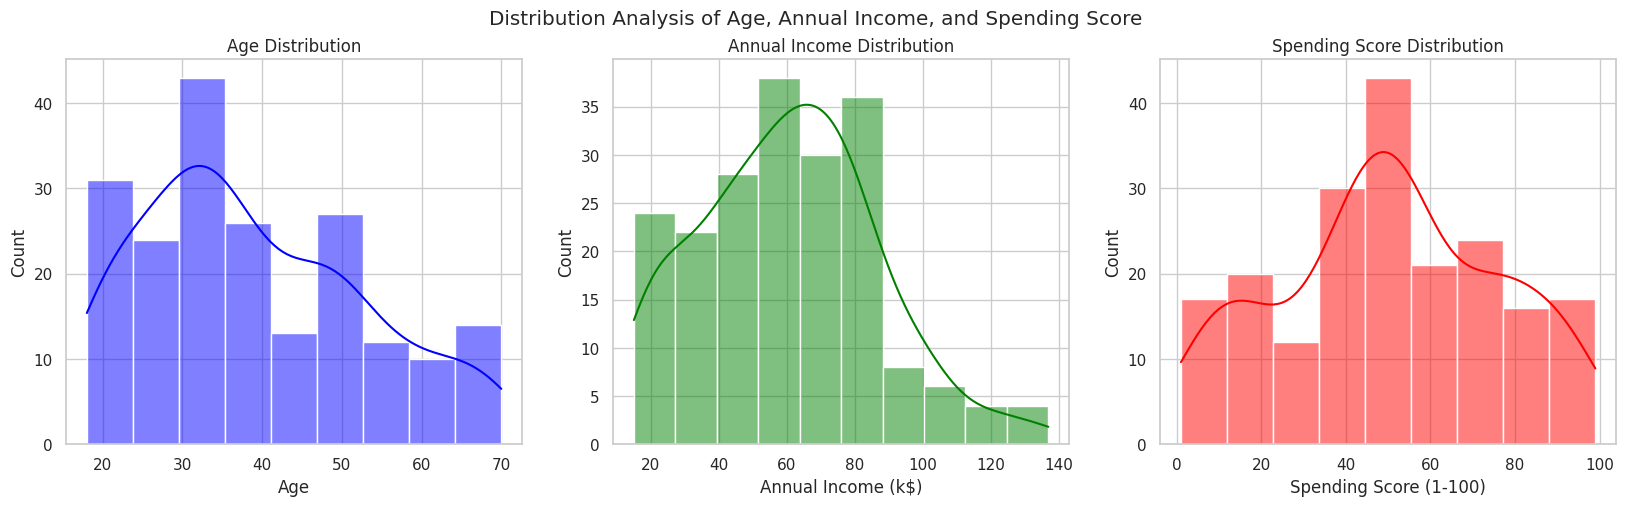

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the seaborn plot
sns.set(style='whitegrid')

# Create a figure and axis objects
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Plot the distribution of age, annual income, and spending score
sns.histplot(data=data, x='Age', kde=True, color='blue', ax=axs[0])
sns.histplot(data=data, x='Annual Income (k$)', kde=True, color='green', ax=axs[1])
sns.histplot(data=data, x='Spending Score (1-100)', kde=True, color='red', ax=axs[2])

# Set the titles of the plots
axs[0].set_title('Age Distribution')
axs[1].set_title('Annual Income Distribution')
axs[2].set_title('Spending Score Distribution')

# Set the title for the entire plot
fig.suptitle('Distribution Analysis of Age, Annual Income, and Spending Score')

# Display the plots
plt.show()


La clientèle du centre commercial est principalement plus jeune, comme l’indique la répartition par âge à gauche. Cela suggère que les offres du centre commercial sont particulièrement attrayantes pour les jeunes. De même, la répartition annuelle des revenus à gauche suggère que le centre commercial attire une clientèle plus riche.

La répartition du score de dépenses est centrée, ce qui indique un mélange équilibré de clients à faible dépense et de clients à forte dépense. Cela suggère que le centre commercial attire un large éventail de clients en termes de comportement de dépenses.L’étape suivante consiste à segmenter les clients en groupes distincts à l’aide d’un algorithme de regroupement basé sur ces caractéristiques.

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])

In [7]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Supposez que df contient vos colonnes 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(data[features])

La normalisation est essentielle avant d’appliquer un algorithme de clustering comme K-Means, car celui-ci est basé sur les distances. Si certaines variables ont des échelles très différentes (ex : revenu en milliers vs score de 1 à 100), elles domineront les autres dans le calcul des distances.

Age

Annual Income (k$)

Spending Score (1-100)

Méthode du coude

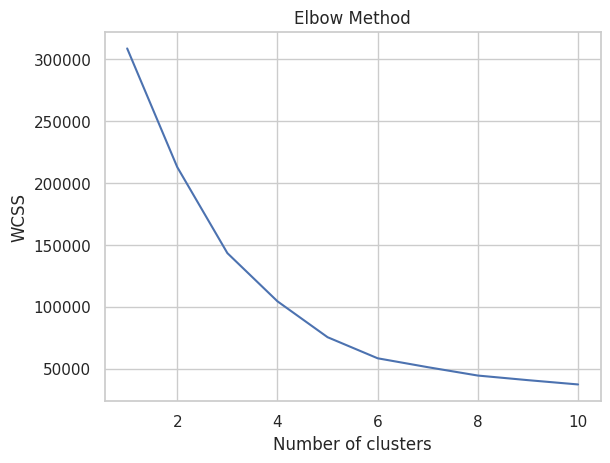

In [9]:
from sklearn.cluster import KMeans

# Select the features to use for clustering
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Determine the optimal number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# Plot the WCSS values
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

K-Means est basé sur la distance euclidienne, ce qui signifie que les variables à grandes échelles auront une influence disproportionnée.

Le MinMaxScaler met toutes les données dans l’intervalle [0, 1], ce qui permet à toutes les variables d’avoir le même poids dans le clustering.

Age, Revenu, Score n’ont pas nécessairement de distribution normale.



In [10]:
#df_scaled

le modèle KMeans avec 5 grappes est une façon de regrouper nos données en 5 catégories distinctes ou « grappes ». Le chiffre 5 est choisi en fonction de la méthode du coude.

Lorsque nous ajustons le modèle, nous demandons à l’algorithme d’apprendre de nos données et de former ces grappes. Pour ce faire, l’algorithme trouve le point central de chaque grappe et attribue chaque point de données à la grappe dont le centre est le plus proche.

Le point où le score commence à diminuer plus lentement (le coude) est considéré comme le nombre optimal de grappes.

In [11]:
# Create the KMeans model with the optimal number of clusters (assumed to be 5 based on the elbow method)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=0)

# Fit the model to the data and predict the cluster labels
labels = kmeans.fit_predict(features)

# Add the cluster labels to the dataframe
data['Cluster'] = labels

# Display the first few rows of the dataframe with the cluster labels
data.head(100)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,0
1,2,1,21,15,81,3
2,3,0,20,16,6,0
3,4,0,23,16,77,3
4,5,0,31,17,40,0
...,...,...,...,...,...,...
95,96,1,24,60,52,2
96,97,0,47,60,47,2
97,98,0,27,60,50,2
98,99,1,48,61,42,2


Une fois le modèle ajusté, il peut prédire à quel groupe appartient un point de données. Ces prédictions, connues sous le nom d'« étiquettes de grappes », sont ensuite ajoutées à nos données originales pour une référence facile.

In [12]:
# Calculate the mean values of Age, Annual Income, and Score for each cluster
cluster_means = data.groupby('Cluster')[
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().astype(int)

# Display the cluster means
cluster_means

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,45,26,20
1,32,86,82
2,43,55,49
3,25,26,78
4,40,87,17


nous avons une idée de l’âge moyen, du revenu annuel et du score de dépenses des clients de chaque groupe, ce qui peut fournir des informations précieuses sur les types de clients qui composent chaque groupe.

Revenu annuel par rapport aux dépenses


En nous basant sur les moyennes que vous avez fournies pour chaque grappe, nous pouvons faire les interprétations suivantes :

Groupe 0 : « Conservateur d’âge moyen » — Cette grappe a tendance à inclure des personnes d’âge moyen (45 ans en moyenne) ayant un revenu annuel relativement faible (26 000 $ en moyenne). Leur score de dépenses est également faible (moyenne de 20), ce qui suggère qu’ils pourraient être plus conservateurs dans leurs dépenses, peut-être en raison de leur faible revenu. Ce groupe pourrait être moins réceptif aux efforts de marketing visant à augmenter les dépenses.

Groupe 1 : « Jeunes à revenu élevé » — Ce groupe comprend les jeunes personnes (32 ans en moyenne) ayant un revenu annuel élevé (86 000 $ en moyenne). Ils ont également un score de dépenses élevé (moyenne de 82), ce qui indique qu’ils dépensent une partie importante de leur revenu. Ce groupe pourrait être une cible clé pour les campagnes de marketing, car ils ont à la fois les moyens et la volonté de dépenser.

Groupe 2 : « Équilibré d’âge moyen » — Ce groupe est composé de personnes d’âge moyen (âge moyen de 43 ans) ayant un revenu annuel modéré (moyenne de 55 k$). Leur score de dépenses se situe à peu près au milieu de la fourchette (moyenne de 49), ce qui suggère une approche équilibrée des dépenses. Les stratégies de marketing pour ce groupe devront peut-être mettre l’accent sur la valeur et la qualité, car ils pourraient être plus exigeants dans leurs dépenses.

Groupe 3 : « Épargnants fortunés » — Ce groupe comprend les personnes d’âge moyen (âge moyen de 40 ans) ayant un revenu annuel élevé :moyenne de 87 000$, mais dont le score de dépenses est faible :moyenne de 17$. Cela suggère que, malgré leur revenu élevé, ils sont conservateurs dans leurs dépenses. Comprendre pourquoi ce groupe ne dépense pas proportionnellement à son revenu pourrait être un élément clé. Ils peuvent apprécier l’épargne ou ne pas voir de valeur dans les offres actuelles.

Groupe 4 : « Jeunes dépensiers » — Ce groupe comprend les jeunes (25 ans en moyenne) ayant un faible revenu annuel (26 000 $ en moyenne), mais leur score de dépenses est élevé (78 en moyenne). Cela suggère que ces personnes, malgré leur faible revenu, sont prêtes à en dépenser une partie importante. Ils peuvent être des acheteurs impulsifs ou ils peuvent valoriser les expériences ou les produits plutôt que les économies d’argent.

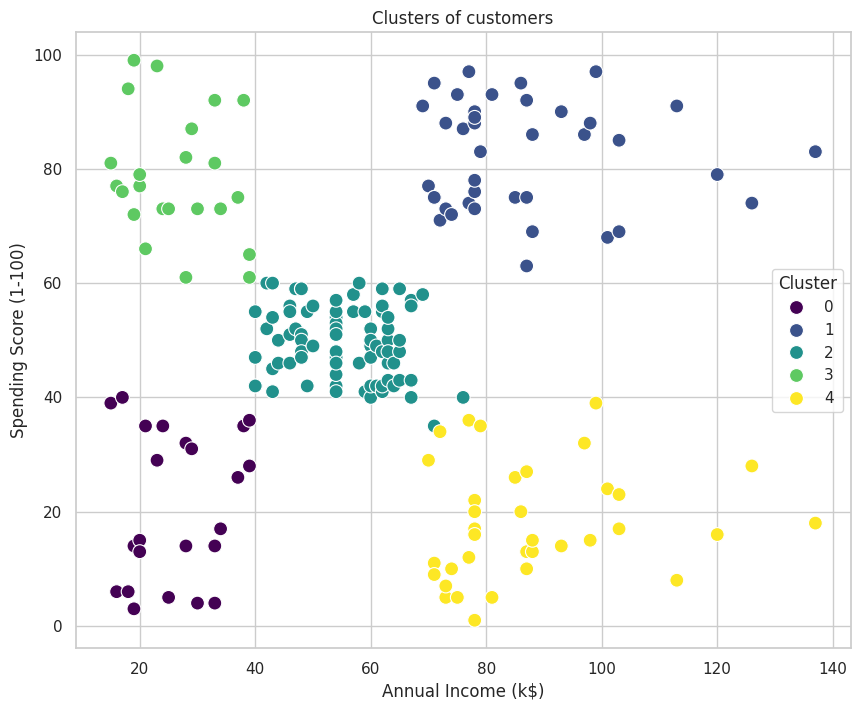

In [13]:
# Create a scatter plot of 'Annual Income (k$)' vs 'Spending Score (1-100)' colored by 'Cluster'
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='viridis', s=100)

# Add a title to the plot
plt.title('Clusters of customers')

# Display the plot
plt.show()

Le nuage de points est une représentation visuelle de la façon dont l’algorithme KMeans a regroupé les clients en grappes en fonction de leur revenu annuel et de leur cote de dépenses. Chaque point du tracé représente un client, et la couleur du point indique à quel groupe appartient le client.

Les grappes que nous avons identifiées donnent une image claire des différents segments de clientèle en fonction de leurs revenus et de leurs habitudes de dépenses.

Faible revenu, faibles dépenses : Les clients ayant un revenu annuel entre 20 et 40k et un score de dépenses entre 0 et 40. Ils ont des revenus plus faibles et ont tendance à dépenser moins.

Revenu élevé, faibles dépenses : Les clients ayant un revenu annuel entre 55 et 140k et un score de dépenses entre 0 et 40. Malgré leurs revenus plus élevés, ils ont tendance à dépenser moins.

Revenu moyen, dépenses moyennes : Les clients ayant un revenu annuel entre 40 et 80k et un score de dépenses entre 40 et 60. Ces clients ont des revenus et des habitudes de consommation modérés. Il s’agit de la grappe la plus concentrée, ce qui indique qu’un grand nombre de clients entrent dans cette catégorie.

Faible revenu, dépenses élevées : Les clients ayant un revenu annuel entre 20 et 40k et un score de dépenses entre 60 et 100. Il est intéressant de noter que ces clients ont des revenus plus faibles, mais ont tendance à dépenser plus.

Revenu élevé, dépenses élevées : Les clients ayant un revenu annuel entre 70 et 140k et un score de dépenses entre 60 et 100. Ces clients ont des revenus plus élevés et ont tendance à dépenser plus.

Segments de clientèle en fonction de l’âge et du score de dépenses

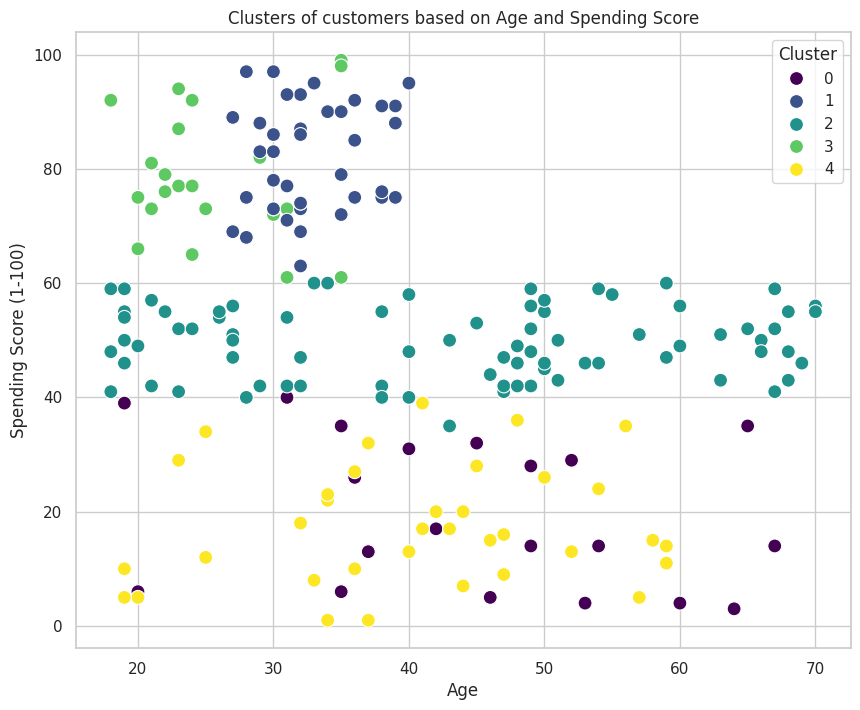

In [14]:
# Create a scatter plot of Age vs Spending Score 
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='Age', y='Spending Score (1-100)', hue='Cluster', 
palette='viridis', s=100)

# Add a title to the plot
plt.title('Clusters of customers based on Age and Spending Score')

# Display the plot
plt.show()

Jeunes dépensiers : Ce groupe représente les jeunes clients qui ont des scores de dépenses élevés. Ils peuvent être attirés par les articles à la mode et sont prêts à dépenser plus. Ces deux groupes comprennent des clients dans la vingtaine et la trentaine avec un score de dépenses entre 60 et 100. Le fait que ces grappes se chevauchent presque pourrait suggérer que l’âge est moins un facteur distinctif chez ces clients qui dépensent beaucoup. Ces clients sont susceptibles d’être les clients de grande valeur du centre commercial en raison de leurs notes de dépenses élevées.

Personnes d’âge moyen, dépensiers modérés : Ce groupe représente les clients d’âge moyen ayant des scores de dépenses modérés. Ils pourraient être plus conservateurs dans leurs habitudes de consommation. Ce groupe comprend des personnes âgées de 20 à 70 ans et un score de dépenses entre 40 et 60 ans. Il s’agit d’une large tranche d’âge, ce qui suggère que le centre commercial attire des clients de différents âges qui ont un score de dépenses modéré. Il pourrait s’agir de la principale clientèle du centre commercial.

Personnes plus âgées et peu dépensières : Ce groupe représente les clients plus âgés qui ont de faibles cotes de dépenses. Ils peuvent être plus économes ou moins attirés par les produits offerts.

Le nuage de points nous permet de visualiser ces segments, fournissant des informations précieuses sur les différents types de clients qui visitent le centre commercial. Ces informations peuvent être utilisées pour adapter les stratégies de marketing et les offres de produits à chaque groupe spécifique.

Répartition par sexe entre les grappes

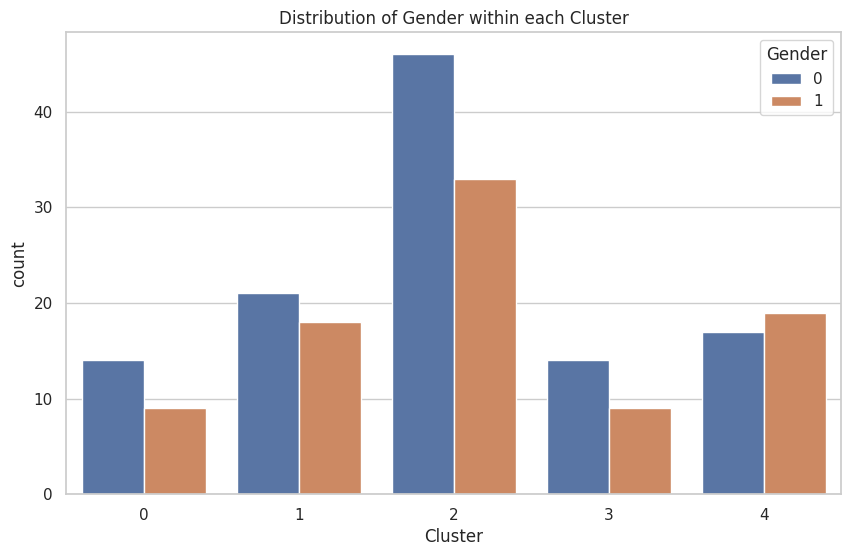

In [15]:
# Create a count plot to show the distribution of 'Gender' within each cluster
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Cluster', hue='Gender')

# Add a title to the plot
plt.title('Distribution of Gender within each Cluster')

# Display the plot
plt.show()

Les grappes présentent généralement une répartition équilibrée entre les sexes, avec quelques écarts intrigants. La grappe 2 se démarque avec une proportion significativement plus élevée de femmes. Cela suggère que les femmes d’âge moyen ayant des habitudes de consommation modérées forment un groupe démographique clé pour ce centre commercial.

Le groupe 3 est le seul groupe où les hommes sont légèrement plus nombreux que les femmes. Cela pourrait indiquer des habitudes d’achat ou des préférences différentes entre les sexes à mesure qu’ils vieillissent. Dans tous les autres groupes, les femmes sont majoritaires, ce qui indique qu’elles constituent une partie importante de la clientèle du centre commercial.

Explorer les relations par paires : un aperçu du graphique par paires

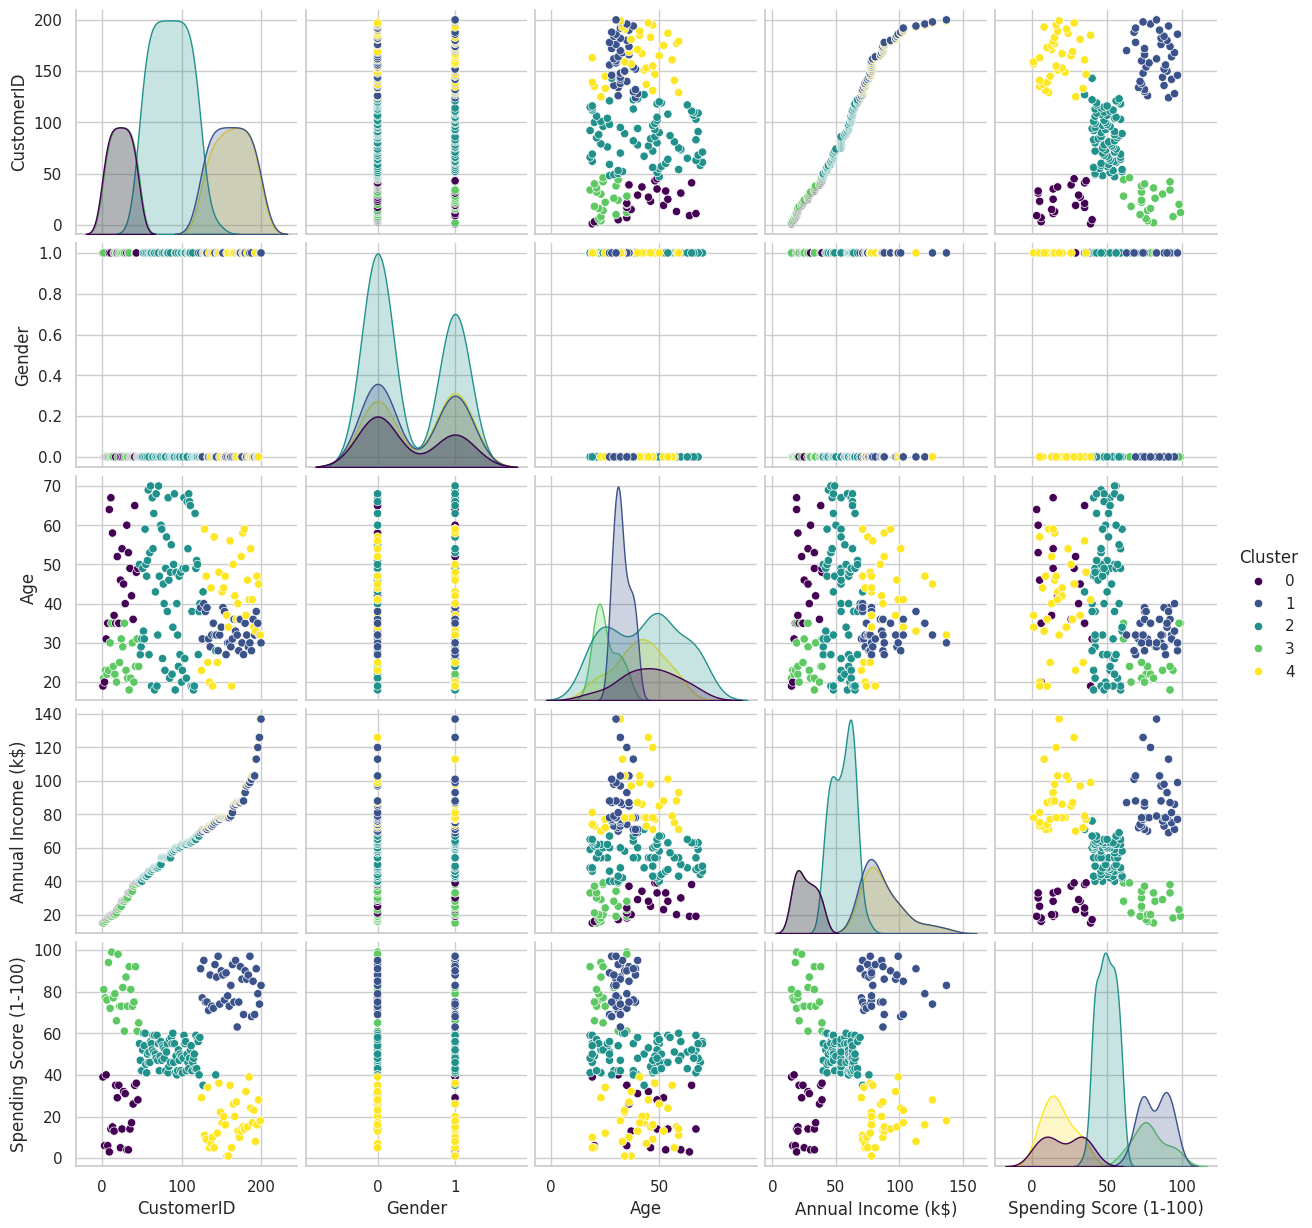

In [16]:
# Create a pairplot for relationships between the different features 
sns.pairplot(data, hue='Cluster', palette='viridis')

# Display the plot
plt.show()

In [17]:
X_numerics = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] # subset with numeric variables only

Les résultats de ce projet peuvent fournir des informations précieuses à l’équipe de marketing. Ils peuvent cibler leurs campagnes de marketing sur les différents segments de clientèle, en fonction de leurs caractéristiques. Ils peuvent également utiliser cette information pour développer de nouveaux produits ou services qui répondent aux besoins et aux préférences spécifiques de chaque segment.